# Arabic Handwritten Digit Recognition using MLP

This notebook trains a normal fully connected Neural Network / MLP for Arabic handwritten digits.

The model uses:
- `Flatten`
- `Dense`
- `Dropout`
- `Dense(10, softmax)`

## 2. Imports and fixed random seeds

In [1]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from datasets import load_dataset
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

np.random.seed(42)
tf.random.set_seed(42)

## 3. Load MADBase dataset

In [2]:
dataset = load_dataset("MagedSaeed/MADBase")
dataset

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-360de881cb44d5(…):   0%|          | 0.00/13.2M [00:00<?, ?B/s]

data/test-00000-of-00001-4fb8430c739afd6(…):   0%|          | 0.00/2.19M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/59999 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/9999 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 59999
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 9999
    })
})

## 4. Show sample images

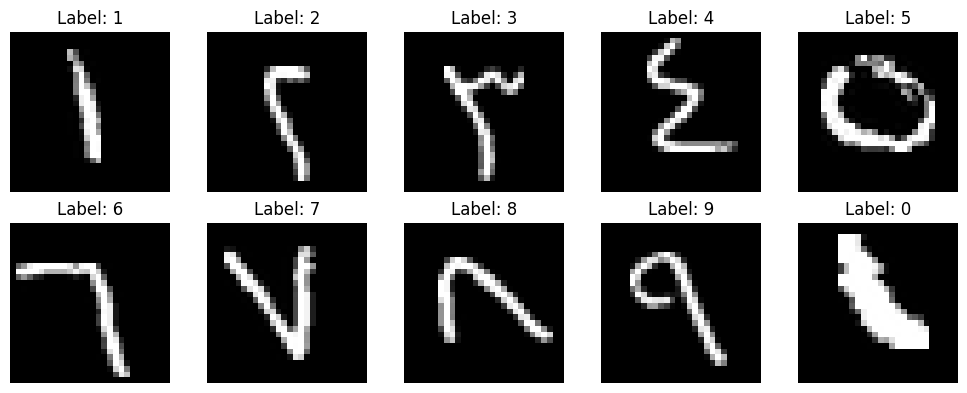

In [3]:
plt.figure(figsize=(10, 4))

for i in range(10):
    image = dataset["train"][i]["image"].convert("L")
    label = dataset["train"][i]["label"]

    plt.subplot(2, 5, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title("Label: " + str(label))
    plt.axis("off")

plt.tight_layout()
plt.show()

## 5. Prepare dataset

The model input will be `(28, 28, 1)` and pixel values will be normalized to `0-1`.

In [4]:
def prepare_dataset(split_name):
    images = []
    labels = []

    for item in dataset[split_name]:
        image = item["image"].convert("L")
        image = np.array(image).astype("float32")

        if image.shape != (28, 28):
            image = cv2.resize(image, (28, 28))

        image = image / 255.0
        image = image.reshape(28, 28, 1)

        images.append(image)
        labels.append(item["label"])

    images = np.array(images, dtype="float32")
    labels = np.array(labels, dtype="int64")

    return images, labels

x_train, y_train = prepare_dataset("train")
x_test, y_test = prepare_dataset("test")

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("x_train:", x_train.shape)
print("y_train:", y_train.shape)
print("x_test:", x_test.shape)
print("y_test:", y_test.shape)

x_train: (59999, 28, 28, 1)
y_train: (59999,)
x_test: (9999, 28, 28, 1)
y_test: (9999,)


## 6. Build MLP model


In [5]:
model = Sequential([
    Flatten(input_shape=(28, 28, 1)),
    Dense(256, activation="relu"),
    Dropout(0.3),
    Dense(128, activation="relu"),
    Dropout(0.2),
    Dense(64, activation="relu"),
    Dense(10, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       200,960 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 242,762 (948.29 KB)

 Trainable params: 242,762 (948.29 KB)

 Non-trainable params: 0 (0.00 B)

## 7. Compile and train

In [6]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

history = model.fit(
    x_train,
    y_train_cat,
    epochs=15,
    batch_size=128,
    validation_split=0.1,
    shuffle=True
)

Epoch 1/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.9313 - loss: 0.2517 - val_accuracy: 0.9797 - val_loss: 0.0723
Epoch 2/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - accuracy: 0.9766 - loss: 0.0828 - val_accuracy: 0.9857 - val_loss: 0.0489
Epoch 3/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.9835 - loss: 0.0575 - val_accuracy: 0.9885 - val_loss: 0.0372
Epoch 4/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 5s 12ms/step - accuracy: 0.9863 - loss: 0.0464 - val_accuracy: 0.9940 - val_loss: 0.0225
Epoch 5/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9884 - loss: 0.0376 - val_accuracy: 0.9925 - val_loss: 0.0259
Epoch 6/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9903 - loss: 0.0329 - val_accuracy: 0.9920 - val_loss: 0.0236
Epoch 7/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 7s 14ms/step - accuracy: 0.9910 - loss: 0.0293 - val_accuracy: 0.9943 - val_loss: 0.0181
Epoch 8/15
422/422 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - accuracy: 0.9912 - loss: 0.0288 - val_accuracy

## 8. Training curves

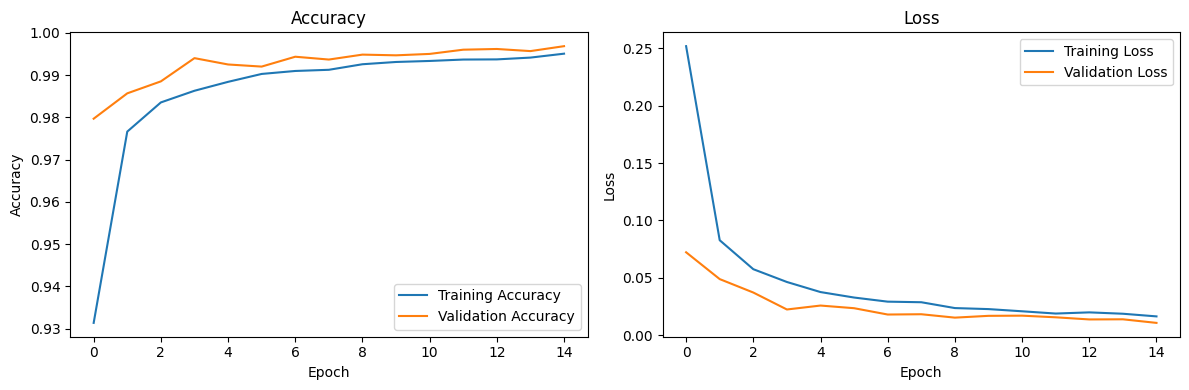

In [7]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Accuracy")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Loss")
plt.legend()

plt.tight_layout()
plt.show()

## 9. Test evaluation

In [8]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

Test Loss: 0.07324033975601196
Test Accuracy: 0.9854985475540161


## 10. Confusion matrix and classification report

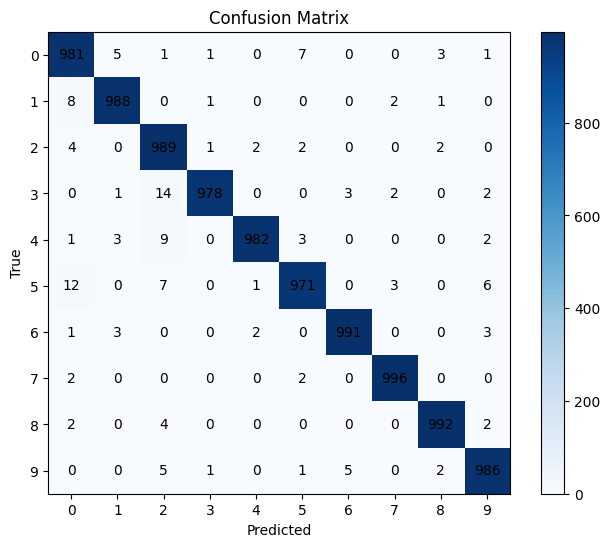

              precision    recall  f1-score   support

           0     0.9703    0.9820    0.9761       999
           1     0.9880    0.9880    0.9880      1000
           2     0.9611    0.9890    0.9749      1000
           3     0.9959    0.9780    0.9869      1000
           4     0.9949    0.9820    0.9884      1000
           5     0.9848    0.9710    0.9778      1000
           6     0.9920    0.9910    0.9915      1000
           7     0.9930    0.9960    0.9945      1000
           8     0.9920    0.9920    0.9920      1000
           9     0.9840    0.9860    0.9850      1000

    accuracy                         0.9855      9999
   macro avg     0.9856    0.9855    0.9855      9999
weighted avg     0.9856    0.9855    0.9855      9999



In [9]:
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(cm, cmap="Blues")
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.colorbar()

for i in range(10):
    for j in range(10):
        plt.text(j, i, cm[i, j], ha="center", va="center", color="black")

plt.xticks(range(10))
plt.yticks(range(10))
plt.show()

print(classification_report(y_test, y_pred, digits=4))

## 11. Image preprocessing and segmentation

This section is important for the mobile app.

The app must do the same idea:
1. Convert image to grayscale or mask.
2. Detect digit pixels.
3. Find bounding boxes.
4. Crop each digit.
5. Resize each digit to 20x20.
6. Put it inside a 28x28 image.
7. Normalize to `0-1`.
8. Send input as `[1, 28, 28, 1]` float32.

For multiple digits, each detected box is predicted separately, then results are joined from left to right.

In [56]:
def create_digit_mask(image_path, use_blue_first=True):
    bgr = cv2.imread(image_path)

    if bgr is None:
        raise ValueError("Image not found: " + image_path)

    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(bgr, cv2.COLOR_BGR2GRAY)
    mask = None

    if use_blue_first:
        hsv = cv2.cvtColor(bgr, cv2.COLOR_BGR2HSV)
        lower_blue = np.array([85, 35, 30])
        upper_blue = np.array([145, 255, 255])
        blue_mask = cv2.inRange(hsv, lower_blue, upper_blue)

        blue_pixels = cv2.countNonZero(blue_mask)
        min_blue_pixels = max(20, int(0.00002 * blue_mask.shape[0] * blue_mask.shape[1]))

        if blue_pixels >= min_blue_pixels:
            mask = blue_mask

    if mask is None:
        blur = cv2.GaussianBlur(gray, (5, 5), 0)
        _, mask = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

    kernel_open = np.ones((2, 2), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel_open)

    kernel_dilate = np.ones((2, 2), np.uint8)
    mask = cv2.dilate(mask, kernel_dilate, iterations=1)

    return rgb, mask

def detect_digit_boxes(mask):
    img_h, img_w = mask.shape
    img_area = img_h * img_w

    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (2, 2))
    mask2 = cv2.dilate(mask, kernel, iterations=1)

    contours, _ = cv2.findContours(mask2, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    boxes = []

    min_area = max(80, img_area * 0.00008)
    min_h = max(8, img_h * 0.018)
    min_w = max(3, img_w * 0.004)

    for cnt in contours:
        x, y, w, h = cv2.boundingRect(cnt)
        area = cv2.contourArea(cnt)

        if area < min_area:
            continue

        if w < min_w or h < min_h:
            continue

        if w > img_w * 0.40 or h > img_h * 0.65:
            continue

        if x < 5 or y < 5 or x + w > img_w - 5 or y + h > img_h - 5:
            continue

        boxes.append((x, y, w, h))

    return sorted(boxes, key=lambda b: b[0])


def center_by_mass(image_28):
    ys, xs = np.nonzero(image_28 > 0.05)

    if len(xs) == 0:
        return image_28

    weights = image_28[ys, xs]
    center_x = np.average(xs, weights=weights)
    center_y = np.average(ys, weights=weights)

    shift_x = int(round(14 - center_x))
    shift_y = int(round(14 - center_y))

    transform = np.float32([[1, 0, shift_x], [0, 1, shift_y]])

    shifted = cv2.warpAffine(image_28, transform, (28, 28), borderValue=0)
    return shifted


def preprocess_digit_from_box(mask, box, padding=8, digit_size=20, target_size=28):
    img_h, img_w = mask.shape
    x, y, w, h = box

    x1 = max(x - padding, 0)
    y1 = max(y - padding, 0)
    x2 = min(x + w + padding, img_w)
    y2 = min(y + h + padding, img_h)

    digit = mask[y1:y2, x1:x2]
    coords = cv2.findNonZero(digit)

    if coords is None:
        return None

    dx, dy, dw, dh = cv2.boundingRect(coords)
    digit = digit[dy:dy + dh, dx:dx + dw]

    h_digit, w_digit = digit.shape
    size = max(h_digit, w_digit)
    square = np.zeros((size, size), dtype=np.uint8)

    x_offset = (size - w_digit) // 2
    y_offset = (size - h_digit) // 2
    square[y_offset:y_offset + h_digit, x_offset:x_offset + w_digit] = digit

    resized = cv2.resize(square, (digit_size, digit_size), interpolation=cv2.INTER_AREA)

    final_img = np.zeros((target_size, target_size), dtype=np.float32)
    start = (target_size - digit_size) // 2
    final_img[start:start + digit_size, start:start + digit_size] = resized.astype("float32") / 255.0
    final_img = center_by_mass(final_img)

    model_input = final_img.reshape(1, target_size, target_size, 1).astype("float32")
    return final_img, model_input


def preprocess_single_digit_image(image_path, show_steps=True):
    rgb, mask = create_digit_mask(image_path)
    boxes = detect_digit_boxes(mask)

    if len(boxes) == 0:
        raise ValueError("No digit detected")

    selected_box = sorted(boxes, key=lambda b: b[2] * b[3], reverse=True)[0]
    result = preprocess_digit_from_box(mask, selected_box)

    if result is None:
        raise ValueError("Could not preprocess the detected digit")

    final_img, model_input = result

    if show_steps:
      debug_img = rgb.copy()
      x, y, w, h = selected_box

      cv2.rectangle(debug_img, (x, y), (x + w, y + h), (0, 255, 0), 2)

      plt.figure(figsize=(6, 5))
      plt.imshow(debug_img)
      plt.title("Detected Digit")
      plt.axis("off")
      plt.show()

    return final_img, model_input

## 12. Predict custom image with Keras

Upload your test image first, then change `image_path`.

In [11]:
from google.colab import files

uploaded = files.upload()
print(list(uploaded.keys()))

Saving 3.jpeg to 3.jpeg
['3.jpeg']


In [57]:
def predict_digit_keras(model_input, model):
    prediction = model.predict(model_input, verbose=0)
    digit = int(np.argmax(prediction))
    confidence = float(np.max(prediction))
    return digit, confidence, prediction


def predict_multiple_digits_keras(image_path, model, show_steps=True):
    rgb, mask = create_digit_mask(image_path)
    boxes = detect_digit_boxes(mask)

    if len(boxes) == 0:
        print("No digits detected.")
        return "", [], []

    predicted_digits = []
    confidences = []

    image_with_boxes = rgb.copy()

    for box in boxes:
        x, y, w, h = box

        result = preprocess_digit_from_box(mask, box)
        if result is None:
            continue

        final_img, model_input = result
        digit, confidence, _ = predict_digit_keras(model_input, model)

        predicted_digits.append(str(digit))
        confidences.append(confidence)

        cv2.rectangle(image_with_boxes, (x, y), (x + w, y + h), (0, 255, 0), 2)

    final_prediction = "".join(predicted_digits)

    if show_steps:
        plt.figure(figsize=(8, 5))
        plt.imshow(image_with_boxes)
        plt.axis("off")
        plt.title(f"Detected Boxes\nFinal Prediction: {final_prediction}", fontsize=16)
        plt.show()

    print("Final Prediction:", final_prediction)

    return final_prediction, predicted_digits, confidences

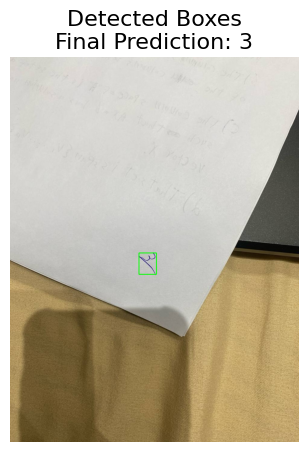

Final Prediction: 3


In [58]:
image_path = "test3.jpg"

final_prediction, predicted_digits, confidences = predict_multiple_digits_keras(
    image_path,
    model,
    show_steps=True
)

## 13. Save Keras model and convert to TFLite

In [45]:
keras_model_path = "arabic_digit_mlp_model.keras"
tflite_model_path = "arabic_digit_mlp_model.tflite"

model.save(keras_model_path)

converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

with open(tflite_model_path, "wb") as file:
    file.write(tflite_model)

print("Saved:", keras_model_path)
print("Saved:", tflite_model_path)

Saved artifact at '/tmp/tmpg37uz16i'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 28, 28, 1), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 10), dtype=tf.float32, name=None)
Captures:
  138628147246096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138628147246864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138628147244752: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138628147245328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138628147248016: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138628147248976: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138628147247632: TensorSpec(shape=(), dtype=tf.resource, name=None)
  138628147247824: TensorSpec(shape=(), dtype=tf.resource, name=None)
Saved: arabic_digit_mlp_model.keras
Saved: arabic_digit_mlp_model.tflite
